<a href="https://colab.research.google.com/github/lovnishverma/iris-demo/blob/main/iris_India_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Notebooks: https://github.com/lovnishverma/Python-Getting-Started

**Outliers:** https://blog.devgenius.io/a-beginners-guide-to-detecting-and-handling-outliers-with-pizza-coffee-examples-243c3a2f1785

https://github.com/lovnishverma/Python-Getting-Started/blob/main/Handling_Outliers.ipynb

**PPT:** https://github.com/lovnishverma/Slidespptspdfs/blob/main/Machine%20Learning/Intro%20to%20Machine%20Learning.pdf

In [69]:
import pandas as pd

In [70]:
df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

In [71]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [72]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [73]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Understanding and Handling Imbalanced Datasets in Classification Models

https://blog.devgenius.io/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

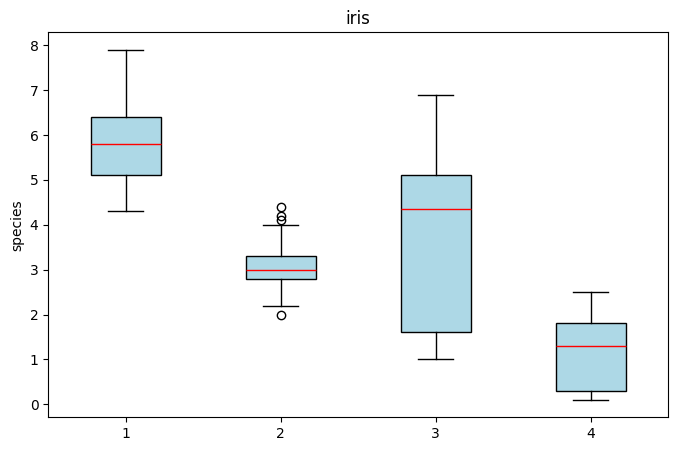

In [74]:
# box plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(x=df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
plt.title("iris")
plt.ylabel("species")
plt.show()


In [75]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


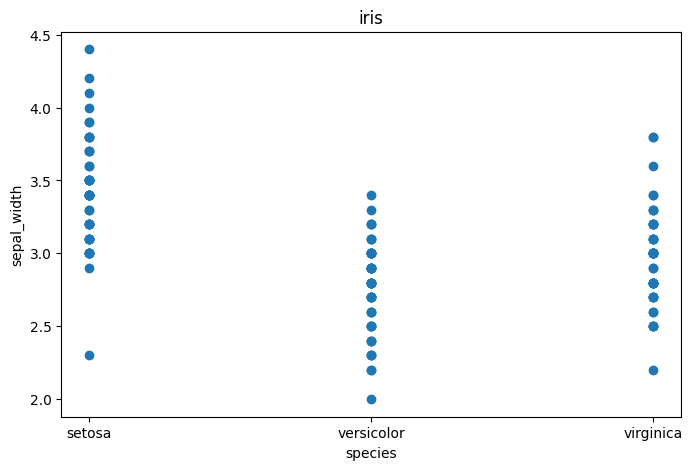

In [76]:
plt.figure(figsize=(8, 5))
plt.scatter(x=df['species'], y=df['sepal_width'])
plt.title("iris")
plt.ylabel("sepal_width")
plt.xlabel("species")
plt.show()


In [77]:
X = df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']] # features

y = df['species'] # Target

Class distribution in full dataset: Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})


/tmp/ipykernel_20946/351278052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


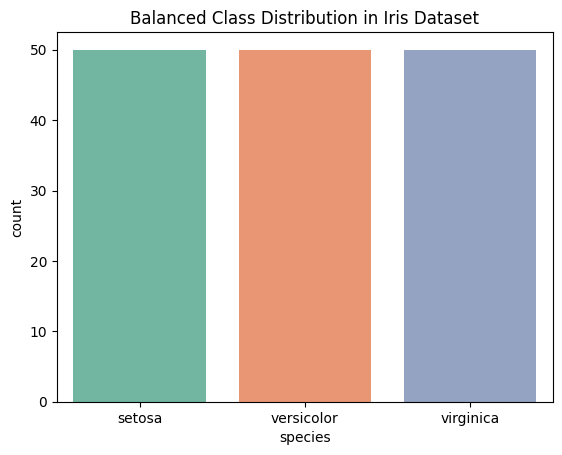

In [78]:
import seaborn as sns
from collections import Counter
print("Class distribution in full dataset:", Counter(y))
sns.countplot(x=y, palette="Set2")
plt.title("Balanced Class Distribution in Iris Dataset")
plt.show()

In [79]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [80]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Test distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({'versicolor': 41, 'setosa': 40, 'virginica': 39})
Test distribution (no stratify): Counter({'virginica': 11, 'setosa': 10, 'versicolor': 9})


In [81]:
from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train distribution (with stratify):", Counter(y_train))
print("Test distribution (with stratify):", Counter(y_test))

Train distribution (with stratify): Counter({'setosa': 40, 'virginica': 40, 'versicolor': 40})
Test distribution (with stratify): Counter({'setosa': 10, 'virginica': 10, 'versicolor': 10})


In [101]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler after the train-test split to avoid data leakage:

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
X_train

array([[-1.72156775, -0.32483982, -1.34703555, -1.32016847],
       [-1.12449223, -1.22612948,  0.41429037,  0.65186742],
       [ 1.14439475, -0.55016223,  0.58474127,  0.25746024],
       [-1.12449223,  0.12580502, -1.29021859, -1.45163753],
       [-0.40800161, -1.22612948,  0.13020555,  0.12599118],
       [ 0.54731923, -1.22612948,  0.6983752 ,  0.91480554],
       [-0.2885865 , -0.77548465,  0.24383948,  0.12599118],
       [ 0.54731923, -0.55016223,  0.75519216,  0.3889293 ],
       [ 2.21913069, -0.0995174 ,  1.32336182,  1.44068178],
       [ 2.21913069,  1.70306192,  1.66426361,  1.30921272],
       [ 2.09971558, -0.0995174 ,  1.60744665,  1.17774366],
       [ 0.18907392, -0.32483982,  0.41429037,  0.3889293 ],
       [-1.00507713, -2.35274155, -0.15387928, -0.268416  ],
       [-0.04975629, -0.77548465,  0.18702251, -0.268416  ],
       [-0.04975629, -1.00080706,  0.13020555, -0.00547788],
       [-1.36332244,  0.35112743, -1.23340162, -1.32016847],
       [-0.88566202,  1.

In [84]:
y_train

,species
8,setosa
106,virginica
76,versicolor
9,setosa
89,versicolor
...,...
37,setosa
2,setosa
33,setosa
52,versicolor


In [85]:
X_test

array([[-1.72156775, -0.0995174 , -1.40385252, -1.32016847],
       [ 0.30848902, -0.0995174 ,  0.64155823,  0.78333648],
       [-1.12449223, -1.45145189, -0.26751321, -0.268416  ],
       [-1.00507713, -1.67677431, -0.26751321, -0.268416  ],
       [-1.72156775,  0.35112743, -1.40385252, -1.32016847],
       [ 0.54731923,  0.57644985,  0.5279243 ,  0.52039836],
       [-1.48273754,  1.25241709, -1.57430342, -1.32016847],
       [-0.52741671,  0.80177226, -1.17658466, -1.32016847],
       [ 0.78614944, -0.0995174 ,  0.81200913,  1.0462746 ],
       [-0.52741671, -0.0995174 ,  0.41429037,  0.3889293 ],
       [ 1.74147027, -0.32483982,  1.43699575,  0.78333648],
       [ 1.26380985,  0.12580502,  0.75519216,  1.44068178],
       [ 0.78614944, -0.0995174 ,  1.15291092,  1.30921272],
       [ 0.66673433,  0.35112743,  0.41429037,  0.3889293 ],
       [-1.00507713,  0.80177226, -1.29021859, -1.32016847],
       [-1.00507713,  0.57644985, -1.34703555, -1.32016847],
       [-0.04975629,  2.

In [86]:
y_test

,species
38,setosa
127,virginica
57,versicolor
93,versicolor
42,setosa
56,versicolor
22,setosa
20,setosa
147,virginica
84,versicolor


In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
model = LogisticRegression(max_iter=1000, random_state=42)


model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [89]:
X_test

array([[-1.72156775, -0.0995174 , -1.40385252, -1.32016847],
       [ 0.30848902, -0.0995174 ,  0.64155823,  0.78333648],
       [-1.12449223, -1.45145189, -0.26751321, -0.268416  ],
       [-1.00507713, -1.67677431, -0.26751321, -0.268416  ],
       [-1.72156775,  0.35112743, -1.40385252, -1.32016847],
       [ 0.54731923,  0.57644985,  0.5279243 ,  0.52039836],
       [-1.48273754,  1.25241709, -1.57430342, -1.32016847],
       [-0.52741671,  0.80177226, -1.17658466, -1.32016847],
       [ 0.78614944, -0.0995174 ,  0.81200913,  1.0462746 ],
       [-0.52741671, -0.0995174 ,  0.41429037,  0.3889293 ],
       [ 1.74147027, -0.32483982,  1.43699575,  0.78333648],
       [ 1.26380985,  0.12580502,  0.75519216,  1.44068178],
       [ 0.78614944, -0.0995174 ,  1.15291092,  1.30921272],
       [ 0.66673433,  0.35112743,  0.41429037,  0.3889293 ],
       [-1.00507713,  0.80177226, -1.29021859, -1.32016847],
       [-1.00507713,  0.57644985, -1.34703555, -1.32016847],
       [-0.04975629,  2.

In [90]:
y_test.head()

,species
38,setosa
127,virginica
57,versicolor
93,versicolor
42,setosa


In [91]:
# Model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



https://www.w3schools.com/python/python_ml_confusion_matrix.asp

In [93]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


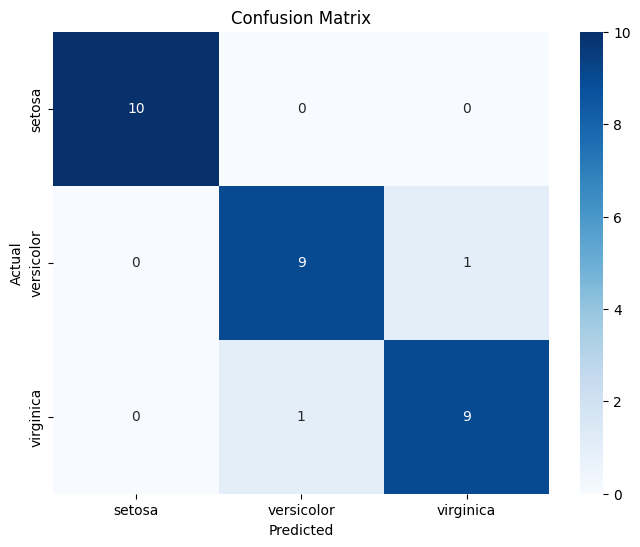

In [94]:
# confusion_matrix using matpotlib with proper labels and title

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_plot.png")
plt.show()

In [95]:
# test on unseen input

features = [[6.7,3.5,5.3,2.5]]


# Scale the input
features_scaled = scaler.transform(features)

# Predict
prediction = model.predict(features_scaled)

print(f" The Predicted flower is: {prediction[0]}")

 The Predicted flower is: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [96]:
# taking input from user

sepal_length = float(input("Enter sepal_length: "))
sepal_width = float(input("Enter sepal_width: "))
petal_length = float(input("Enter petal_length: "))
petal_width = float(input("Enter petal_width: "))

features = [[sepal_length, sepal_width, petal_length, petal_width]]
features_scaled = scaler.transform(features)
prediction = model.predict(features_scaled)

print(prediction[0])

Enter sepal_length: 6.7
Enter sepal_width: 3.5
Enter petal_length: 5.3
Enter petal_width: 2.5
virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [97]:
import joblib

# save model

joblib.dump(model, "model.joblib")

['model.joblib']

In [98]:
# save scaler

joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']

In [99]:
# load model

loaded_model = joblib.load("model.joblib")

# load scaler
scaler = joblib.load("scaler.joblib")

In [100]:
features = [[6.7,3.5,5.3,2.5]]


# Scale the input
features_scaled = scaler.transform(features)

# Predict
prediction = loaded_model.predict(features_scaled)

print(f" The Predicted flower is: {prediction[0]}")

 The Predicted flower is: virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Note: *you can safely ignore these warnings. They are not errors and do not affect the prediction.*

What's Next: https://github.com/lovnishverma/iris-demo

Live Demo: https://iris-demo-gjle.onrender.com/



---

